In [2]:
# STEP 1: Load the Dataset
import pandas as pd

df = pd.read_csv("uber.csv")  
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
# STEP 2: Understand the Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
df.describe(include="all")

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
unique,NaN,200000,NaN,196629,NaN,NaN,NaN,NaN,NaN
top,NaN,2015-05-07 19:52:06.0000003,NaN,2014-04-13 18:19:00 UTC,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,4,NaN,NaN,NaN,NaN,NaN
mean,2.771250e+07,NaN,11.359955,NaN,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,NaN,9.901776,NaN,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,NaN,-52.000000,NaN,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,NaN,6.000000,NaN,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,NaN,8.500000,NaN,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,NaN,12.500000,NaN,-73.967154,40.767158,-73.963658,40.768001,2.000000


In [7]:
# STEP 3: Data Cleaning
#Remove missing values
df = df.dropna()

In [8]:
#Remove invalid fares
df = df[df['fare_amount'] > 0]

In [9]:
#remove invalid passengers
df = df[df['passenger_count'] > 0]

In [10]:
# Feature Engineering
#Convert datetime:

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['Hour'] = df['pickup_datetime'].dt.hour
df['Day'] = df['pickup_datetime'].dt.day_name()
df['Month'] = df['pickup_datetime'].dt.month_name()

In [11]:
#STEP 4: Create Distance Column (KEY ANALYSIS)

#Uber pricing depends on distance → very important!

import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

<Axes: title={'center': 'Fare Distribution'}, ylabel='Frequency'>

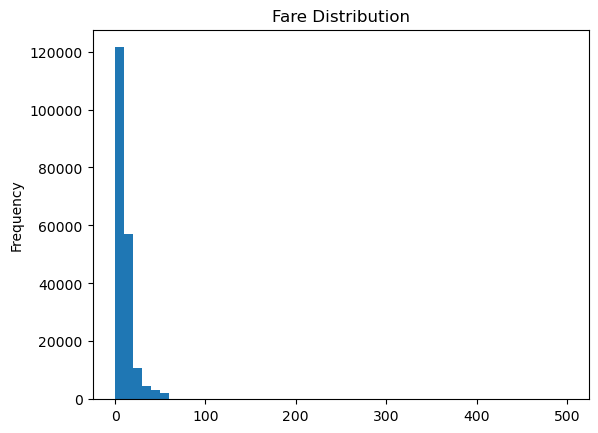

In [12]:
#STEP 6: Exploratory Data Analysis (EDA)
#1. Fare Distribution
df['fare_amount'].plot(kind='hist', bins=50, title='Fare Distribution')

<Axes: title={'center': 'Rides by Hour'}, xlabel='Hour'>

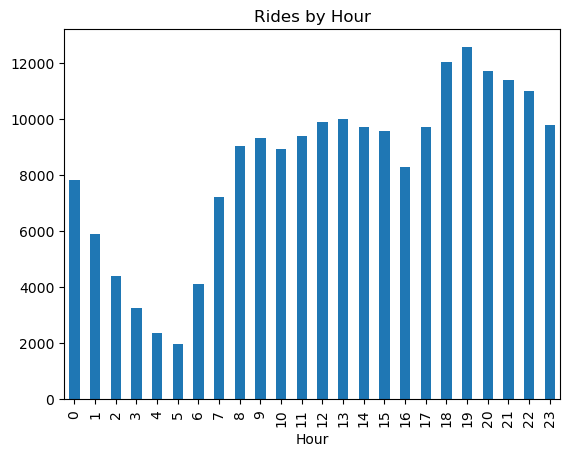

In [13]:
#2. Rides by Hour
df['Hour'].value_counts().sort_index().plot(kind='bar', title='Rides by Hour')

<Axes: title={'center': 'Rides by Day'}, xlabel='Day'>

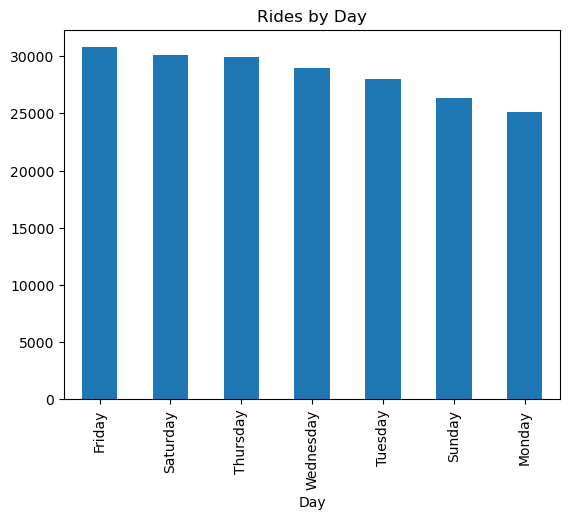

In [14]:
#3. Rides by Day
df['Day'].value_counts().plot(kind='bar', title='Rides by Day')

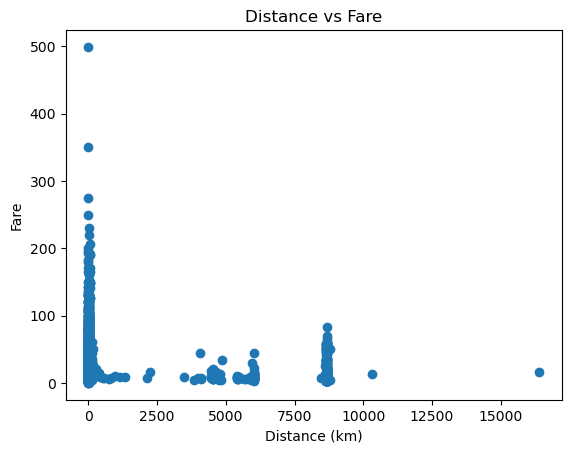

In [16]:
#4. Distance vs Fare
import matplotlib.pyplot as plt

plt.scatter(df['distance_km'], df['fare_amount'])
plt.xlabel("Distance (km)")
plt.ylabel("Fare")
plt.title("Distance vs Fare")
plt.show()

<Axes: title={'center': 'Passenger Count'}, xlabel='passenger_count'>

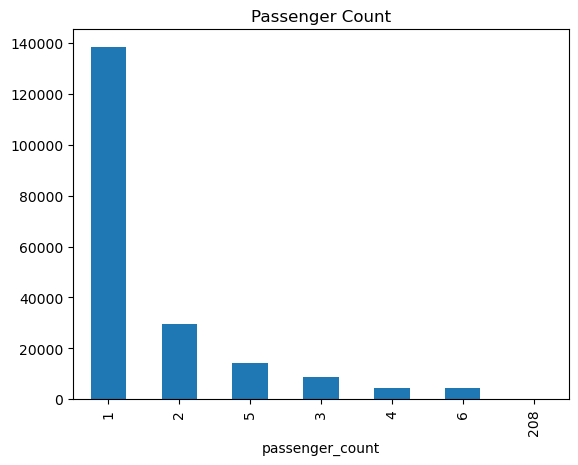

In [17]:
#5. Passenger Count
df['passenger_count'].value_counts().plot(kind='bar', title='Passenger Count')